In [18]:
import json
import pandas as pd
import re
import mygene


# get 2019(or other version) OT dga

In [20]:
# File path to the full 2019 JSON file
input_file = "/itf-fi-ml/shared/users/ziyuzh/svm/data/opentarget/2017/17.02_association_data.json"

rows = []

with open(input_file, "r") as f:
    for line in f:
        obj = json.loads(line)

        gene_id = obj["target"]["id"]
        disease_id = obj["disease"]["id"]
        datasources = obj["association_score"]["datasources"]

        for datasource_id, score in datasources.items():
            if score > 0:  # optional: skip zero scores
                rows.append({
                    "ot_version": "17.02",
                    "gene_id": gene_id,
                    "EFO": disease_id,
                    "datasource_id": datasource_id,
                    "score": score
                })

# Convert to pandas DataFrame
df = pd.DataFrame(rows)

In [21]:
df.head(3)

,ot_version,gene_id,EFO,datasource_id,score
0,17.02,ENSG00000113721,EFO_0000616,expression_atlas,0.225325
1,17.02,ENSG00000113721,EFO_0000616,gene2phenotype,1.000000
2,17.02,ENSG00000113721,EFO_0000616,uniprot_literature,1.000000


In [22]:
diseaseid_map = pd.read_csv('/itf-fi-ml/shared/users/ziyuzh/svm/data/opentarget/ICD2EFO_map.tsv',sep = '\t')

In [23]:
diseaseid_map = diseaseid_map[['MAPPED_TERM_URI','ICD10_CODE/SELF_REPORTED_TRAIT_FIELD_CODE']]
diseaseid_map.rename(columns={"MAPPED_TERM_URI": "EFO"}, inplace=True)
diseaseid_map.rename(columns={"ICD10_CODE/SELF_REPORTED_TRAIT_FIELD_CODE": "disease_id"}, inplace=True)
diseaseid_map.dropna(inplace=True)

In [25]:
icd_dict = {
    'Certain infectious and parasitic diseases': ['A00', 'B99'],
    'Neoplasms': ['C00', 'D48'],
    'Diseases of the blood and blood-forming organs and certain disorders involving the immune mechanism': ['D50', 'D89'],
    'Endocrine, nutritional and metabolic diseases': ['E00', 'E90'],
    'Mental and behavioural disorders': ['F00', 'F99'],
    'Diseases of the nervous system': ['G00', 'G99'],
    'Diseases of the eye and adnexa': ['H00', 'H59'],
    'Diseases of the ear and mastoid process': ['H60', 'H95'],
    'Diseases of the circulatory system': ['I00', 'I99'],
    'Diseases of the respiratory system': ['J00', 'J99'],
    'Diseases of the digestive system': ['K00', 'K93'],
    'Diseases of the skin and subcutaneous tissue': ['L00', 'L99'],
    'Diseases of the musculoskeletal system and connective tissue': ['M00', 'M99'],
    'Diseases of the genitourinary system': ['N00', 'N99']
}

# Preprocess ICD ranges for fast lookup
icd_ranges = []
for category, (start, end) in icd_dict.items():
    icd_ranges.append((start, end))

def icd_in_range(icd_code):
    icd_code = icd_code.strip().upper()
    if len(icd_code) != 3:
        return False
    if not (icd_code[0].isalpha() and icd_code[1:].isdigit()):
        return False

    for start, end in icd_ranges:
        if start[0] == end[0] == icd_code[0]:
            if int(start[1:]) <= int(icd_code[1:]) <= int(end[1:]):
                return True
    return False

In [26]:
diseaseid_map_filtered = diseaseid_map[diseaseid_map['disease_id'].apply(icd_in_range)]

In [27]:
len(diseaseid_map_filtered),len(diseaseid_map_filtered['disease_id'].unique())

(526, 523)

In [28]:
diseaseid_map_filtered["EFO"] = diseaseid_map_filtered["EFO"].str.replace(" ", "")
diseaseid_map_filtered["EFO"] = diseaseid_map_filtered["EFO"].str.split(",")

# Step 2: Explode the EFO column
diseaseid_map_filtered = diseaseid_map_filtered.explode("EFO", ignore_index=True)

/tmp/ipykernel_2388834/380514731.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  diseaseid_map_filtered["EFO"] = diseaseid_map_filtered["EFO"].str.replace(" ", "")
/tmp/ipykernel_2388834/380514731.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  diseaseid_map_filtered["EFO"] = diseaseid_map_filtered["EFO"].str.split(",")


In [29]:
disease_set = set()
for i in diseaseid_map_filtered['EFO'].tolist():
    if ',' in i:
        disease_set.update(set(i.split(',')))
    else:
        disease_set.add(i)


In [32]:
assocations_df = df[df['EFO'].isin(disease_set)]

In [34]:
len(df[df['EFO'].isin(disease_set)])

506891

In [35]:
assocations_df = assocations_df.copy()
# assocations_df.rename(columns={"disease_id": "EFO"}, inplace=True)

assocations_df = assocations_df.merge(diseaseid_map_filtered, how='left', on='EFO')

In [36]:
assocations_df['disease_id'] = 'ICD10_'+assocations_df['disease_id']

In [37]:
assocations_df.columns

Index(['ot_version', 'gene_id', 'EFO', 'datasource_id', 'score', 'disease_id'], dtype='object')

In [38]:
assocations_df = assocations_df[['gene_id','disease_id','score']]

In [39]:
print(len(assocations_df))
assocations_df = assocations_df.drop_duplicates(subset=['gene_id','disease_id'])
print(len(assocations_df))


970839
667252


In [40]:
mg = mygene.MyGeneInfo()
# Query mygene for UniProt and Entrez gene ID mappings
results = mg.querymany(
    assocations_df['gene_id'].unique().tolist(),
    scopes='ensembl.gene',
    fields='uniprot',
    species='human'
)
results_df = pd.DataFrame(results)
results_df = results_df[~results_df['uniprot'].isna()]
results_df['uniprot_ids'] = results_df['uniprot'].apply(
    lambda x: list(x.values())[0] if isinstance(x, dict) and 'Swiss-Prot' in x else None)
results_df = results_df[~results_df['uniprot_ids'].isna()]
results_df[results_df['uniprot_ids'].apply(lambda x: isinstance(x, list) and len(x) > 1)]
results_df = results_df[['query','uniprot_ids']]

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
12 input query terms found dup hits:	[('ENSG00000226519', 2), ('ENSG00000280018', 2), ('ENSG00000227110', 2), ('ENSG00000278932', 3), ('E
557 input query terms found no hit:	['ENSG00000283186', 'ENSG00000130489', 'ENSG00000166748', 'ENSG00000116957', 'ENSG00000243135', 'ENS


In [41]:
def explode_all_list_columns(df):
    for col in df.columns:
        if df[col].apply(lambda x: isinstance(x, list)).any():
            df = df.explode(col, ignore_index=True)
    return df


map_df = explode_all_list_columns(results_df)
print(len(map_df))
map_df = map_df.drop_duplicates()
print(len(map_df))


17944
17944


In [ ]:
map_df

In [42]:
assocations_df.rename(columns={"gene_id": "query"}, inplace=True)
assocations_df = assocations_df.merge(map_df,how='left',on='query')

In [43]:
assocations_df = assocations_df[['uniprot_ids','disease_id','score']]
assocations_df = assocations_df.drop_duplicates(subset=['uniprot_ids','disease_id'])

In [44]:
assocations_df.to_csv('/itf-fi-ml/shared/users/ziyuzh/svm/data/opentarget/2017/row_dga_2017.csv',index=False)

# get newest dga

In [ ]:
import pandas as pd
import numpy as np
import re
import mygene

In [ ]:
ot_disease = pd.read_parquet('/itf-fi-ml/shared/users/ziyuzh/svm/data/opentarget/disease/disease.parquet')

In [ ]:
# ICD10 dictionary
icd_dict = {
    'Certain infectious and parasitic diseases': ['A00', 'B99'],
    'Neoplasms': ['C00', 'D48'],
    'Diseases of the blood and blood-forming organs and certain disorders involving the immune mechanism': ['D50', 'D89'],
    'Endocrine, nutritional and metabolic diseases': ['E00', 'E90'],
    'Mental and behavioural disorders': ['F00', 'F99'],
    'Diseases of the nervous system': ['G00', 'G99'],
    'Diseases of the eye and adnexa': ['H00', 'H59'],
    'Diseases of the ear and mastoid process': ['H60', 'H95'],
    'Diseases of the circulatory system': ['I00', 'I99'],
    'Diseases of the respiratory system': ['J00', 'J99'],
    'Diseases of the digestive system': ['K00', 'K93'],
    'Diseases of the skin and subcutaneous tissue': ['L00', 'L99'],
    'Diseases of the musculoskeletal system and connective tissue': ['M00', 'M99'],
    'Diseases of the genitourinary system': ['N00', 'N99']
}

# Preprocess ICD ranges for fast lookup
icd_ranges = []
for category, (start, end) in icd_dict.items():
    icd_ranges.append((start, end))

# Function to check if an ICD10 code is within the defined ranges
def icd_in_range(icd_code):
    match = re.match(r'^ICD10:([A-Z]\d{2})$', icd_code.strip())
    if match:
        code = match.group(1)
        for start, end in icd_ranges:
            if start[0] == end[0] == code[0]:  # Same starting letter
                if int(start[1:]) <= int(code[1:]) <= int(end[1:]):
                    return True
    return False

# Function to get the first matching ICD10 code in a row
def get_icd_code(row):
    if isinstance(row, np.ndarray):
        for ref in row:
            if isinstance(ref, str) and icd_in_range(ref):
                return ref.strip()  # Return the first matching ICD10 code
    return None

filtered_df = ot_disease[ot_disease['dbXRefs'].apply(get_icd_code).notnull()].copy()

filtered_df['icd'] = filtered_df['dbXRefs'].apply(get_icd_code)



In [ ]:
folder_path = '/itf-fi-ml/shared/users/ziyuzh/svm/data/opentarget/association_overall_direct'

# Read all parquet parts at once
df = pd.read_parquet(folder_path, engine='pyarrow')

In [ ]:
filtered_dga = df[df['diseaseId'].isin(filtered_df['id'].unique())]
filtered_dga = filtered_dga.rename(columns={'diseaseId': 'id'})
merged_df = pd.merge(filtered_dga, filtered_df[['id', 'icd']], on='id', how='outer')
unique_rows = merged_df.drop_duplicates(subset=['icd', 'targetId'])

In [ ]:
unique_rows = unique_rows.copy()
unique_rows['disease_id'] = unique_rows['icd'].str.replace(':', '_')

unique_rows = unique_rows[['targetId','disease_id','score']]

In [ ]:
mg = mygene.MyGeneInfo()
# Query mygene for UniProt and Entrez gene ID mappings
results = mg.querymany(
    unique_rows['targetId'].unique().tolist(),
    scopes='ensembl.gene',
    fields='uniprot',
    species='human'
)
results_df = pd.DataFrame(results)
results_df = results_df[~results_df['uniprot'].isna()]
results_df['uniprot_ids'] = results_df['uniprot'].apply(
    lambda x: list(x.values())[0] if isinstance(x, dict) and 'Swiss-Prot' in x else None)
results_df = results_df[~results_df['uniprot_ids'].isna()]
results_df[results_df['uniprot_ids'].apply(lambda x: isinstance(x, list) and len(x) > 1)]
results_df = results_df[['query','uniprot_ids']]

In [ ]:
def explode_all_list_columns(df):
    for col in df.columns:
        if df[col].apply(lambda x: isinstance(x, list)).any():
            df = df.explode(col, ignore_index=True)
    return df


map_df = explode_all_list_columns(results_df)
print(len(map_df))
map_df = map_df.drop_duplicates()
print(len(map_df))


In [ ]:
unique_rows.rename(columns={"targetId": "query"}, inplace=True)


unique_rows = unique_rows.merge(map_df,how='left',on='query')
unique_rows = unique_rows[['uniprot_ids','disease_id','score']]
unique_rows = unique_rows.drop_duplicates(subset=['uniprot_ids','disease_id'])

In [ ]:
unique_rows.to_csv('/itf-fi-ml/shared/users/ziyuzh/svm/data/opentarget/row_dga_2025.csv',index=False)

# assign time label

In [1]:
import pandas as pd

In [51]:
# time_dga = pd.read_csv('/itf-fi-ml/shared/users/ziyuzh/svm/data/opentarget/2019/row_dga_2019.csv')
time_dga = pd.read_csv('/itf-fi-ml/shared/users/ziyuzh/svm/data/opentarget/2017/row_dga_2017.csv')

newest_dga = pd.read_csv('/itf-fi-ml/shared/users/ziyuzh/svm/data/opentarget/row_dga_2025.csv')

In [52]:
time_dga.columns,newest_dga.columns

(Index(['uniprot_ids', 'disease_id', 'score'], dtype='object'),
 Index(['uniprot_ids', 'disease_id', 'score'], dtype='object'))

In [54]:
# delete unreliable infor in old version
print(len(time_dga))
time_dga = time_dga.merge(newest_dga[['uniprot_ids', 'disease_id']], how='inner',on=['uniprot_ids', 'disease_id'])
print(len(time_dga))
time_dga['first_pub_year'] = 2017

91651
91651


In [55]:
time_dga.to_csv('/itf-fi-ml/shared/users/ziyuzh/svm/data/opentarget/2017/reliable_dga_2017.csv',index=False)

# final merge

In [57]:
time_2019 = pd.read_csv('/itf-fi-ml/shared/users/ziyuzh/svm/data/opentarget/2019/reliable_dga_2019.csv')
time_2017 = pd.read_csv('/itf-fi-ml/shared/users/ziyuzh/svm/data/opentarget/2017/reliable_dga_2017.csv')
time_2025 = pd.read_csv('/itf-fi-ml/shared/users/ziyuzh/svm/data/opentarget/row_dga_2025.csv')

In [58]:
time_2019.columns,time_2017.columns,time_2025.columns

(Index(['uniprot_ids', 'disease_id', 'score', 'first_pub_year'], dtype='object'),
 Index(['uniprot_ids', 'disease_id', 'score', 'first_pub_year'], dtype='object'),
 Index(['uniprot_ids', 'disease_id', 'score'], dtype='object'))

In [59]:
# Step 1: Extract key pairs from 2017 and 2019
keys_2017 = set(tuple(x) for x in time_2017[['uniprot_ids', 'disease_id']].values)
keys_2019 = set(tuple(x) for x in time_2019[['uniprot_ids', 'disease_id']].values)

# Step 2: Define function to assign year
def assign_pub_year(row):
    key = (row['uniprot_ids'], row['disease_id'])
    if key in keys_2017:
        return 2017
    elif key in keys_2019:
        return 2019
    else:
        return 2025

# Step 3: Apply function to time_2025
time_2025['first_pub_year'] = time_2025.apply(assign_pub_year, axis=1)


In [62]:
time_2025['first_pub_year'].value_counts()

first_pub_year
2025    162745
2017     91651
2019     29641
Name: count, dtype: int64

In [63]:
time_2025.to_csv('/itf-fi-ml/shared/users/ziyuzh/svm/data/opentarget/ot_dga_time_uni.csv',index=False)

In [ ]:
import matplotlib.pyplot as plt

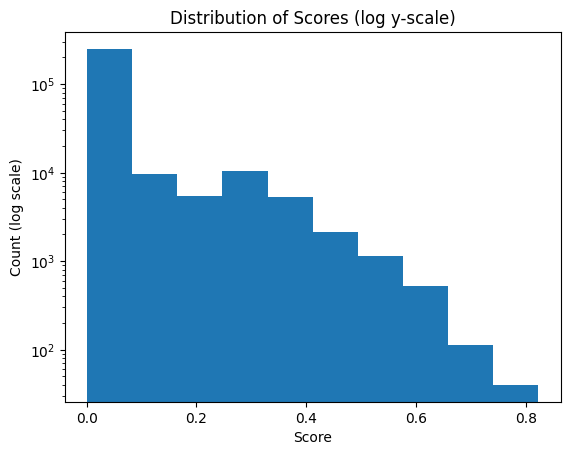

In [65]:
plt.hist(time_2025['score'], log=True)
plt.xlabel("Score")
plt.ylabel("Count (log scale)")
plt.title("Distribution of Scores (log y-scale)")
plt.show()

In [68]:
len(time_2025[time_2025['score']>=0.4]),len(time_2025[time_2025['score']>=0.3]),len(time_2025[time_2025['score']>=0.2])

(4348, 12649, 22659)

In [69]:
import pandas as pd

In [70]:
time_2025=pd.read_csv('/itf-fi-ml/shared/users/ziyuzh/svm/data/opentarget/ot_dga_time_uni.csv')

In [78]:
time_2025['first_pub_year'] = time_2025['first_pub_year'].replace(2019, 2018)
time_2025['first_pub_year'] = time_2025['first_pub_year'].replace(2017, 2016)

In [79]:
len(time_2025[time_2025['score']>=0.4]['disease_id'].unique())

249

In [81]:
all_df = time_2025[time_2025['score']>=0.4]
time = 2019
selected_diseases = []
for disease_id in all_df['disease_id'].unique():
    sub_df = all_df[all_df['disease_id']==disease_id]
    if len(sub_df) < 15:
        continue
    else:
        # print(type(time),type(sub_df['first_pub_year'].max()))
        if sub_df['first_pub_year'].max() > time and sub_df['first_pub_year'].min() <= time and len(sub_df[sub_df['first_pub_year']<time]) >=5:
            selected_diseases.append(disease_id)
print(len(selected_diseases))

57


In [83]:
time_2025.columns

Index(['uniprot_ids', 'disease_id', 'score', 'first_pub_year'], dtype='object')

In [84]:
time_2025.rename(columns={"uniprot_ids": "string_id"}, inplace=True)

In [85]:
time_2025.to_csv('/itf-fi-ml/shared/users/ziyuzh/svm/data/opentarget/ot_dga_time_uni.csv',index=False)